In [5]:
import requests
from bs4 import BeautifulSoup as bs
import re

In [11]:
list_url = [
"https://www.localiza.com/chile/es-cl/viaja-en-auto/santiago",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-monteria",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/feria-de-las-flores",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-santa-marta",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/cartagena",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-valledupar",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-mendoza",
"https://www.localiza.com/colombia/es-co/viaja-en-auto",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/viajar-por-colombia-en-carro-tips-y-recomendaciones",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/Santiago",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-el-carnaval-de-barranquilla",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-el-calafate",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-villavicencio-capital-del-meta",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-salta",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-apartado",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-rio-gallegos",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/medellin",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-cordoba",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-las-fiestas-del-mar-en-santa-marta",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/bariloche",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-cano-cristales",
"https://www.localiza.com/ecuador/es-ec/viaja-en-auto/cotopaxi",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-la-isla-san-andres",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-el-eje-cafetero",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-jujuy",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-el-festival-vallenato-en-valledupar",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-popayan",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/calama",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-la-guajira",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-las-fiestas-de-independencia-en-cartagena",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-cali",
"https://www.localiza.com/chile/es-cl/viaja-en-auto",
"https://www.localiza.com/paraguay/es-py/viaja-en-auto/alto-parana",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/Calama",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/bogota",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-la-feria-bonita-en-bucaramanga",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/antofagasta",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/puerto-montt",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-rosario",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-bahia-malaga-y-buenaventura",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/la-serena",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-las-vacaciones-de-invierno",
"https://www.localiza.com/uruguay/es-uy/viaja-en-auto",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-el-rio-guejar",
"https://www.localiza.com/ecuador/es-ec/viaja-en-auto",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/barranquilla",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/buenos-aires-la-gran-metropoli-de-america-del-sur",
"https://www.localiza.com/brasil-site/es-es/viaja-en-auto",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-el-desierto-de-la-tatacoa",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/La-Serena",
"https://www.localiza.com/paraguay/es-py/viaja-en-auto",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/copiapo",
"https://www.localiza.com/mexico/es-mx/viaja-en-auto",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/Puerto-Montt",
"https://m.localiza.com/chile/es-cl/viaja-en-auto",
"https://www.localiza.com/chile/es-cl/viaja-en-auto/Copiapo",
"https://www.localiza.com/colombia-site/es-co/viaja-en-auto",
"https://m.localiza.com/paraguai/es-py/viaja-en-auto/ALTOPARANA",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-villa-general-belgrano",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/Cali",
"https://m.localiza.com/paraguai/es-py/viaja-en-auto/ASUNCION",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/SantaMarta",
"https://www.localiza.com/ecuador/es-ec/viaja-en-auto/Cuenca",
"https://m.localiza.com/paraguai/es-py/viaja-en-auto/AMAMBAY",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/santamarta",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/cordoba",
"https://www.localiza.com/Uruguay/es-uy/viaja-en-auto",
"https://www.localiza.com/ecuador/es-ec/viaja-en-auto/mindo",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/Barranquilla",
"https://www.localiza.com/paraguay/es-py/viaja-en-auto/AMAMBAY",
"https://m.localiza.com/paraguai/es-py/viaja-en-auto/CORDILLERA",
"https://www.localiza.com/colombia/es-co/viaja-en-auto/que-hacer-en-bogota",
"https://www.localiza.com/argentina/es-ar/viaja-en-auto/Salta",
"https://m.localiza.com/paraguai/es-py/viaja-en-auto/ITAPUA",
"https://www.localiza.com/paraguay/es-py/viaja-en-auto/Hidroelectrica-Binacional-Itaipu-Cataratas-Ciudad-del-Este",
"https://m.localiza.com/paraguai/es-py/viaja-en-auto/CENTRAL",
"https://www.localiza.com/paraguay/es-py/viaja-en-auto/itapua"
]

In [15]:
url = "https://www.localiza.com/argentina/es-ar/viaja-en-auto/que-hacer-en-villa-general-belgrano"
r = requests.get(url)
r = r.content

soup = bs(r)
print(soup.prettify())

<!DOCTYPE html>
<html lang="es-ar">
 <head>
  <meta charset="utf-8"/>
  <title>
   ¿Qué hacer en Villa General Belgrano? - Tips de viaje | Localiza
  </title>
  <meta content="Viví momentos inolvidables en Villa General Belgrano. ¡Conocé el mejor plan para tu viaje! " name="description"/>
  <meta content="index, follow" name="robots"/>
  <base href="/"/>
  <meta content="width=device-width, initial-scale=1.00" name="viewport"/>
  <meta content="#01602A" name="theme-color"/>
  <meta content="yes" name="apple-mobile-web-app-capable"/>
  <meta content="#01602A" name="apple-mobile-web-app-status-bar-style"/>
  <link as="style" href="https://cdn-prod.securiti.ai/consent/cookie-consent.css" rel="stylesheet preload preconnect" type="text/css"/>
  <link href="./favicon.ico" rel="shortcut icon" type="image/x-icon"/>
  <link href="/apple-touch-icon.png" rel="apple-touch-icon" sizes="180x180"/>
  <link href="/favicon-32x32.png" rel="icon" sizes="32x32" type="image/png"/>
  <link href="/favicon-16

In [ ]:
if soup.find(text="Item indisponível no momento"):
    print(url,"Item Indisponível!")
else:
    print("OK!")

In [ ]:
soup.p

In [ ]:
links = soup.find_all('a')
links

In [ ]:
for i in links:
    i.get('href')
    print(i.get('href'))

In [ ]:
texto = soup.find_all('p')
texto

In [ ]:
soup.get_text()

# Blog Itatiaia - para PLN

In [10]:
blog = "https://blog.araujo.com.br/coronavirus/limpeza-do-carro-em-epoca-de-coronavirus/"
r = requests.get(blog)
html_page = r.content

soup = bs(html_page, 'lxml')

FeatureNotFound: Couldn't find a tree builder with the features you requested: lxml. Do you need to install a parser library?

In [9]:
paragrafo = soup.find_all('p')
paragrafo = [ re.findall("<p>(.*?)</p>", str(frase)) for frase in paragrafo ]
paragrafo = [ re.sub("<(.*?)>", "", str(frase)) for frase in paragrafo ] 
paragrafo = list(set(paragrafo))
paragrafo = " ".join(paragrafo)
paragrafo

''

In [ ]:
conteudo = soup.find("div", { "class" : "entry-content" })
conteudo.text

'A orientação é não circular; é ficar em casa. Mas se for preciso sair, como se proteger do coronavírus e fazer corretamente a limpeza do carro? Tem medidas de higienização a serem tomadas?O médico infectologista Lucas Chaves é bem claro: “se estiver com sintomas de gripe, não é para sair de casa e ponto, a não ser que tenha falta de ar, então a recomendação é procurar um serviço de saúde. Para os assintomáticos, a orientação é higienizar as mãos.”O médico explica que o carro é como se fosse uma extensão da nossa casa, inclusive com os mesmos grupos de bactérias e vírus que circulam na família. Assim, como não é recomendado sair nem receber ninguém em casa neste momento, a regra vale para o carro também, ou seja, evitar dar e pegar carona.Um estudo feito nos Estados Unidos apontou que a parte mais suja (contaminada por bactérias e fungos) é o volante. Por isso, ele deve receber atenção especial na hora da limpeza do carro. Para quem transporta filhos e outras pessoas dentro do veículo 

In [ ]:
h1 = soup.find_all('h1')
h1 = re.findall(">(.*?)<", str(h1))
h1[0]

'Limpeza do carro em época de coronavírus'

In [ ]:
h2 = soup.find_all('h2')
h2 = re.findall(">(.*?)<", str(h2))
"".join(h2)

'Rotina de limpeza do carro, Outra pessoa usou o carro?, Quais produtos não devo usar?, Alguém espirrou o tossiu dentro do carro, Como evitar o desgaste por excesso de limpeza do carro?, Vidros: abertos ou fechados?'

# Melhor para Blog

In [ ]:
def pega_textos(url):
    html_page = requests.get(url)
    soup = bs(html_page.text, 'lxml')
    #conteudo
    conteudo = soup.find("div", { "class" : "entry-content" })
    texto = conteudo.find_all('p')
    texto = [i.text for i in texto]
    texto = " ".join(texto)
    #h1
    h1 = soup.find('h1')
    h1 = h1.text
    #h2
    h2 = soup.find_all('h2')
    h2 = [i.text for i in h2]
    h2 = " ".join(h2)
    #unindo
    texto_completo = h1 + " " + h2 + " " + texto

    return texto_completo

In [ ]:
h1 = soup.find('h1')
h1.text

'Limpeza do carro em época de coronavírus'

In [ ]:
h2 = soup.find_all('h2')
h2 = [i.text for i in h2]
h2 = " ".join(h2)
h2

'Rotina de limpeza do carro Outra pessoa usou o carro? Quais produtos não devo usar? Alguém espirrou o tossiu dentro do carro Como evitar o desgaste por excesso de limpeza do carro? Vidros: abertos ou fechados?'

In [ ]:
blog = "https://blog.araujo.com.br/coronavirus/limpeza-do-carro-em-epoca-de-coronavirus/"
html_page = requests.get(blog)
#Soup fica com o mesmo html mas é possível fazer buscas
soup = bs(html_page.text, 'lxml')

In [ ]:
conteudo = soup.find("div", { "class" : "entry-content" })

texto = conteudo.find_all('p')
texto = [i.text for i in texto]

texto = " ".join(texto)
texto

' A orientação é não circular; é ficar em casa. Mas se for preciso sair, como se proteger do coronavírus e fazer corretamente a limpeza do carro? Tem medidas de higienização a serem tomadas? O médico infectologista Lucas Chaves é bem claro: “se estiver com sintomas de gripe, não é para sair de casa e ponto, a não ser que tenha falta de ar, então a recomendação é procurar um serviço de saúde. Para os assintomáticos, a orientação é higienizar as mãos.” O médico explica que o carro é como se fosse uma extensão da nossa casa, inclusive com os mesmos grupos de bactérias e vírus que circulam na família. Assim, como não é recomendado sair nem receber ninguém em casa neste momento, a regra vale para o carro também, ou seja, evitar dar e pegar carona. Um estudo feito nos Estados Unidos apontou que a parte mais suja (contaminada por bactérias e fungos) é o volante. Por isso, ele deve receber atenção especial na hora da limpeza do carro. Para quem transporta filhos e outras pessoas dentro do veíc

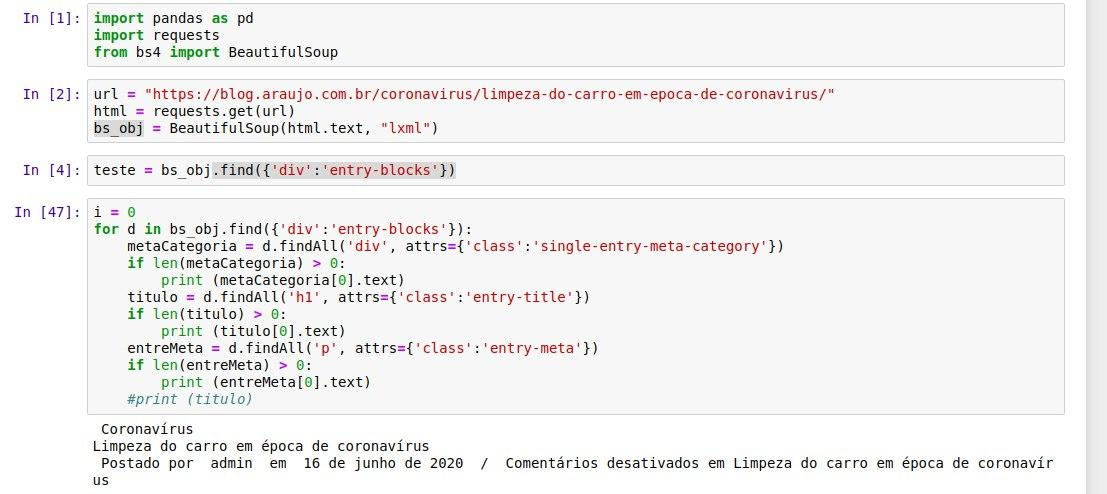

# Pegar Tag GTM

In [ ]:
url = 'https://minhaitatiaia.com.br/loja'

In [ ]:
r = requests.get(url)
html_page = r.content
html_page = str(html_page)
html_page

'b\'<!doctype html>\\n<html lang="pt">\\n    <head prefix="og: http://ogp.me/ns# fb: http://ogp.me/ns/fb# product: http://ogp.me/ns/product#">\\n        <script>\\n    var BASE_URL = \\\'https://minhaitatiaia.com.br/loja/\\\';\\n    var require = {\\n        "baseUrl": "https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR"\\n    };\\n</script>\\n        <meta charset="utf-8"/>\\n<meta name="description" content="Sofistica\\xc3\\xa7\\xc3\\xa3o e qualidade traduzidas em arm\\xc3\\xa1rios e eletros. #cozinhasitatiaia"/>\\n<meta name="robots" content="INDEX,FOLLOW"/>\\n<meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=1.0"/>\\n<meta name="format-detection" content="telephone=no"/>\\n<title>Loja Virtual Cozinhas Itatiaia</title>\\n<link  rel="stylesheet" type="text/css"  media="all" href="https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR/mage/calendar.css" />\

In [ ]:
head = re.findall("<head(.*)</head>", html_page)
head = str(head)
re.findall("GTM-NVVK27T", head)

['GTM-NVVK27T']

In [ ]:
body = re.findall("<body(.*)</body>", html_page)
body = str(body)
re.findall("GTM-NVVK27T", body)

['GTM-NVVK27T']

In [ ]:
r = requests.get(url)
html_page = r.content
soup = bs(html_page, "lxml")

head = soup.head
body = soup.body

head

<head prefix="og: http://ogp.me/ns# fb: http://ogp.me/ns/fb# product: http://ogp.me/ns/product#">
<script>
    var BASE_URL = 'https://minhaitatiaia.com.br/loja/';
    var require = {
        "baseUrl": "https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR"
    };
</script>
<meta charset="utf-8"/>
<meta content="Sofisticação e qualidade traduzidas em armários e eletros. #cozinhasitatiaia" name="description"/>
<meta content="INDEX,FOLLOW" name="robots"/>
<meta content="width=device-width, initial-scale=1, maximum-scale=1.0" name="viewport"/>
<meta content="telephone=no" name="format-detection"/>
<title>Loja Virtual Cozinhas Itatiaia</title>
<link href="https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR/mage/calendar.css" media="all" rel="stylesheet" type="text/css"/>
<link href="https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR/DigitalHu

In [ ]:

body

<body><p> 

<!--
<script src="https://cdn.onesignal.com/sdks/OneSignalSDK.js" async=""></script>
<script>
  var OneSignal = window.OneSignal || [];
  OneSignal.push(function() {
    OneSignal.init({
      appId: "bb30e286-4a86-4f26-b533-a0bd7a3a0082",
    });
  });
</script>
-->
<meta content="Cozinhas Itatiaia" property="og:title"/>
<meta content="website" property="og:type"/>
<meta content="https://minhaitatiaia.com.br/loja/" property="og:url"/>
<meta content="https://minhaitatiaia.com.br/media/logo/stores/1/logo_1.png" property="og:image"/>
<meta content="Sofisticação e qualidade traduzidas em armários e eletros. #cozinhasitatiaia" property="og:description"/>
<script type="text/javascript">
window.dataLayer = window.dataLayer || [];
dataLayer.push({"ecommerce":{"currencyCode":"BRL"},"pageType":"cms_index_index","list":"other"});
</script>
<!-- Google Tag Manager by MagePal -->
<script>(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':
new Date().getTime(),event:'gtm.js'});va

In [ ]:
body.find(text=re.compile("GTM-NVVK27T"))

"(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':\nnew Date().getTime(),event:'gtm.js'});var f=d.getElementsByTagName(s)[0],\nj=d.createElement(s),dl=l!='dataLayer'?'&l='+l:'';j.async=true;j.src=\n'//www.googletagmanager.com/gtm.js?id='+i+dl;f.parentNode.insertBefore(j,f);\n})(window,document,'script','dataLayer','GTM-NVVK27T');"

In [ ]:
soup.body.find(text=re.compile("GTM-NVVK27T"))

"(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':\nnew Date().getTime(),event:'gtm.js'});var f=d.getElementsByTagName(s)[0],\nj=d.createElement(s),dl=l!='dataLayer'?'&l='+l:'';j.async=true;j.src=\n'//www.googletagmanager.com/gtm.js?id='+i+dl;f.parentNode.insertBefore(j,f);\n})(window,document,'script','dataLayer','GTM-NVVK27T');"

In [ ]:
head.find(text="GTM-NVVK27T")

In [ ]:
head

<head prefix="og: http://ogp.me/ns# fb: http://ogp.me/ns/fb# product: http://ogp.me/ns/product#">
<script>
    var BASE_URL = 'https://minhaitatiaia.com.br/loja/';
    var require = {
        "baseUrl": "https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR"
    };
</script>
<meta charset="utf-8"/>
<meta content="Sofisticação e qualidade traduzidas em armários e eletros. #cozinhasitatiaia" name="description"/>
<meta content="INDEX,FOLLOW" name="robots"/>
<meta content="width=device-width, initial-scale=1, maximum-scale=1.0" name="viewport"/>
<meta content="telephone=no" name="format-detection"/>
<title>Loja Virtual Cozinhas Itatiaia</title>
<link href="https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR/mage/calendar.css" media="all" rel="stylesheet" type="text/css"/>
<link href="https://minhaitatiaia.com.br/static/version1599892856/frontend/DigitalHub/theme-itatiaia-mobile/pt_BR/DigitalHu

In [ ]:
body

<body><p> 

<!--
<script src="https://cdn.onesignal.com/sdks/OneSignalSDK.js" async=""></script>
<script>
  var OneSignal = window.OneSignal || [];
  OneSignal.push(function() {
    OneSignal.init({
      appId: "bb30e286-4a86-4f26-b533-a0bd7a3a0082",
    });
  });
</script>
-->
<meta content="Cozinhas Itatiaia" property="og:title"/>
<meta content="website" property="og:type"/>
<meta content="https://minhaitatiaia.com.br/loja/" property="og:url"/>
<meta content="https://minhaitatiaia.com.br/media/logo/stores/1/logo_1.png" property="og:image"/>
<meta content="Sofisticação e qualidade traduzidas em armários e eletros. #cozinhasitatiaia" property="og:description"/>
<script type="text/javascript">
window.dataLayer = window.dataLayer || [];
dataLayer.push({"ecommerce":{"currencyCode":"BRL"},"pageType":"cms_index_index","list":"other"});
</script>
<!-- Google Tag Manager by MagePal -->
<script>(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':
new Date().getTime(),event:'gtm.js'});va

In [ ]:
import urllib3
import re
from bs4 import BeautifulSoup

http = urllib3.PoolManager()

response = http.request('GET', url)
soup = BeautifulSoup(response.data,"html.parser")

GTM = soup.head.findAll(text=re.compile(r'GTM'))
print(GTM)

/usr/local/lib/python3.6/dist-packages/urllib3/connectionpool.py:847: InsecureRequestWarning: Unverified HTTPS request is being made. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
  InsecureRequestWarning)
/usr/local/lib/python3.6/dist-packages/urllib3/connectionpool.py:847: InsecureRequestWarning: Unverified HTTPS request is being made. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
  InsecureRequestWarning)


["(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':\nnew Date().getTime(),event:'gtm.js'});var f=d.getElementsByTagName(s)[0],\nj=d.createElement(s),dl=l!='dataLayer'?'&l='+l:'';j.async=true;j.src=\n'//www.googletagmanager.com/gtm.js?id='+i+dl;f.parentNode.insertBefore(j,f);\n})(window,document,'script','dataLayer','GTM-NVVK27T');"]
